
# Project: Investigate a Dataset (Medical Appointment No Shows )

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

we will be investigating the dataset of 100K medical appointments of Brazil Health system, figuring out the relation between certain condition and the patient showing at the clinic
the dataset dictionary:

- PatientId: Identification of a patient
- AppointmentID: Identification of each appointment
- Gender: Male and Female
- ScheduledDay: The day someone called or registered the appointment, this is before appointment of course.
- AppointmentDay: The day of the actuall appointment, when they have to visit the doctor.
- Age: How old is the patient.
- Neighbourhood: Where the appointment takes place.
- Scholarship: True(1) or False(0), weather the patient is in the Bolsa Família program
- Hipertension: True(1) or False(0), weather the patient is hypertensive or not.
- Diabetes: True(1) or False(0),weather the patient is diabetic or not.
- Alcoholism: True(1) or False(0) ,weather the patient is alcoholic or not.
- Handcap: True(1) or False(0), weather the patient is Handicaped or not.
- SMS_received: True(1) or False(0), 1 or more messages sent to the patient.
- No-show: Yes for not showing and No for showing.

In [1]:
#Importing liberaries that will be used
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as snb

<a id='wrangling'></a>
## Data Wrangling


### General Properties

In [2]:
#Loading the data file, checked and it is a 'CSV' file, so no need to define the separator
df = pd.read_csv('noshowappointments-kagglev2-may-2016 .csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
#loading information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


Findings:
- no Null Values in the dataset

In [170]:
#loading number of rows and columns
df.shape

(110521, 14)

- the dataset has 110527 rows and 14 columns

In [5]:
#getting summary about the dataset
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


Findings:
- the MIN of the age column is -1, which indicates a typo or an outlier in our dataset
- the MAX is also 115 which not seems reasonable, we will be limiting our data without them

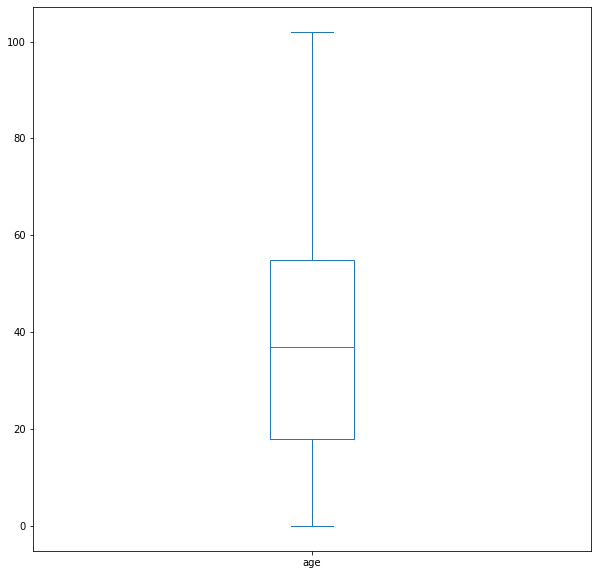

In [169]:
#create box plot to spot outliers
df['age'].plot(kind = 'box', figsize = (10,10));

Findings:
- there is outlier of 115 in age but the -1 isn't showing in the boxplot

In [7]:
#checking for duplicates
df.duplicated().sum()

0

In [8]:
#looping over each columns to get duplicates
columns = df.columns.tolist()
any_duplicates = {}
for column in columns:
    a = df[column].duplicated().sum()
    any_duplicates[column] = a
any_duplicates

{'PatientId': 48228,
 'AppointmentID': 0,
 'Gender': 110525,
 'ScheduledDay': 6978,
 'AppointmentDay': 110500,
 'Age': 110423,
 'Neighbourhood': 110446,
 'Scholarship': 110525,
 'Hipertension': 110525,
 'Diabetes': 110525,
 'Alcoholism': 110525,
 'Handcap': 110522,
 'SMS_received': 110525,
 'No-show': 110525}

Findings:
- PatientId has 48228 which may mean that the same patient has visited the clinic more than once
- any other duplication is normal

In [9]:
#looking for the unique values 
unique_values = {}
for column in columns:
    a = df[column].nunique()
    unique_values[column] = a
unique_values

{'PatientId': 62299,
 'AppointmentID': 110527,
 'Gender': 2,
 'ScheduledDay': 103549,
 'AppointmentDay': 27,
 'Age': 104,
 'Neighbourhood': 81,
 'Scholarship': 2,
 'Hipertension': 2,
 'Diabetes': 2,
 'Alcoholism': 2,
 'Handcap': 5,
 'SMS_received': 2,
 'No-show': 2}

Findings:
- Handcap has 5 unique values, also the dictionary of the dataset declared that is either True(1) or False(0)
- rest of the rows has logical unique values

### Data Cleaning 
- converting column labels to all lowercase for better handling
- Fixing typos
- dropping irrelevant(outlier) values/rows
- replacing column names dashes with underscores, also adding underscores for some labels
- modifying the Handcaped row to hold only two values

In [10]:
#converting columns names all to lower case
df.columns = [x.lower() for x in df.columns]

In [11]:
# fixing the typo within hipertension column and renaming 'patientid', 'appointmentid', 'scheduledday'.'no-show'.
df.rename(columns={'patientid': 'patient_id', 'appointmentid': 'appointment_id', 'scheduledday': 'scheduled_day',
                            'appointmentday': 'appointment_day', 'hipertension': 'hypertension', 'no-show': 'no_show',
                           'handcap': 'handicaped'}, inplace=True)

In [12]:
# dropping the outliers
df = df.drop(df[df.age < 0].index)
df = df.drop(df[df.age > 110].index)

In [13]:
#replacing handicaped values of '2','3','4' to be '1'
df.loc[df.handicaped > 0, 'handicaped'] = 1

### Confirming Changes

In [14]:
#confirming changes for columns labels
df.head()

,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicaped,sms_received,no_show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


- all columns labels are lowercase and the underscores have been added

In [15]:
#confirming changes after dropping the outliers
df.describe()

,patient_id,appointment_id,age,scholarship,hypertension,diabetes,alcoholism,handicaped,sms_received
count,1.105210e+05,1.105210e+05,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000
mean,1.474921e+14,5.675304e+06,37.085694,0.098271,0.197248,0.071869,0.030401,0.020240,0.321034
std,2.560928e+14,7.129576e+04,23.104606,0.297682,0.397923,0.258272,0.171690,0.140823,0.466876
min,3.921784e+04,5.030230e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172457e+12,5.640285e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.172598e+13,5.680569e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.438963e+13,5.725523e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,102.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


- -1, 115 entries in the age row have been dropped

In [16]:
#confirming changes after modifying the handicapes column unique values
df.handicaped.nunique()

2

- handicaped entries have been set to only two - 0 for False and 1 for True

In [17]:
#sepeating the patient into two groups, show and not shows
patient_show = df['no_show'] == 'No'
patient_not_show = df['no_show'] == 'Yes'

<a id='eda'></a>
## Exploratory Data Analysis

### Question 1
#### what is the percentage of patients not showing ?

Text(0.5, 1.0, 'Percentage showing or not')

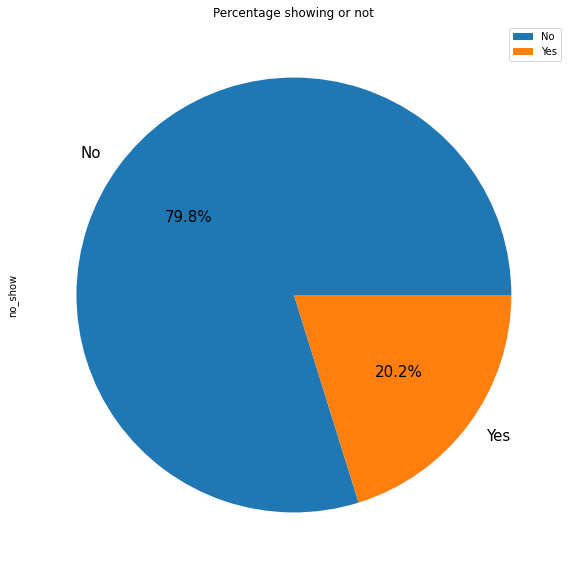

In [48]:
#plotting the percentage of show/now show of all the patients
df['no_show'].value_counts(normalize=True).plot(kind = 'pie', figsize= (10,10), fontsize = 15, autopct='%1.1f%%')
plt.legend();
plt.title('Percentage showing or not')

- 20.2 of all the patients has not came to clinic

### Question 2
#### does gender affect presence of the patient at the clinic ?

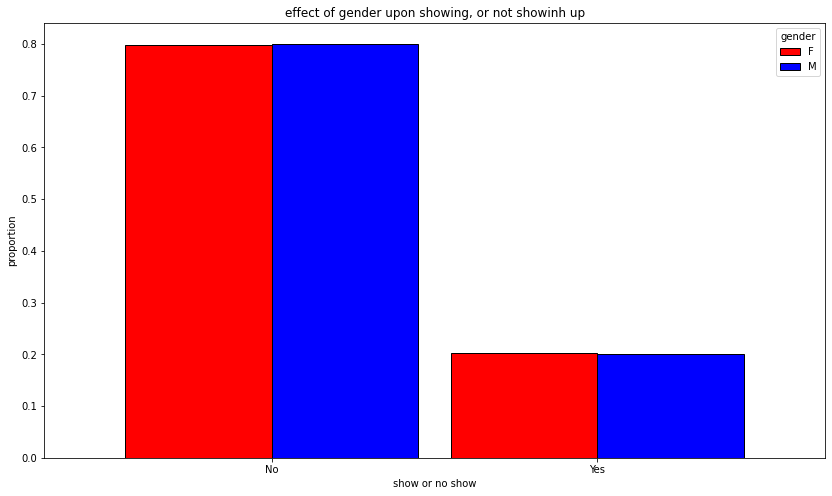

In [93]:
#ploting the proportion of gender show up
df.groupby('gender')['no_show'].value_counts(normalize=True).unstack('gender').plot.bar(edgecolor='black',
                                                                                        figsize= [14,8],
                                                                                        rot=0,
                                                                                        width=0.9,
                                                                                        color=['red', 'blue']);
plt.title('effect of gender upon showing, or not showinh up');
plt.xlabel('show or no show');
plt.ylabel('proportion');



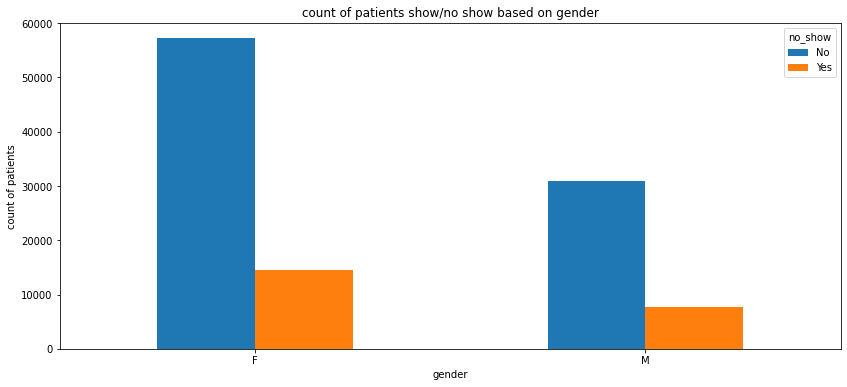

In [96]:
#plotting the count of patients show/no show based on gender
gen_sho = df.groupby('gender')['no_show'].value_counts(normalize=False).unstack()
gen_sho_labels = ['Female', 'Male']
gen_sho.plot(kind = 'bar', figsize=(14, 6), rot=0);
plt.title('count of patients show/no show based on gender')
plt.xlabel('gender')
plt.ylabel('count of patients');

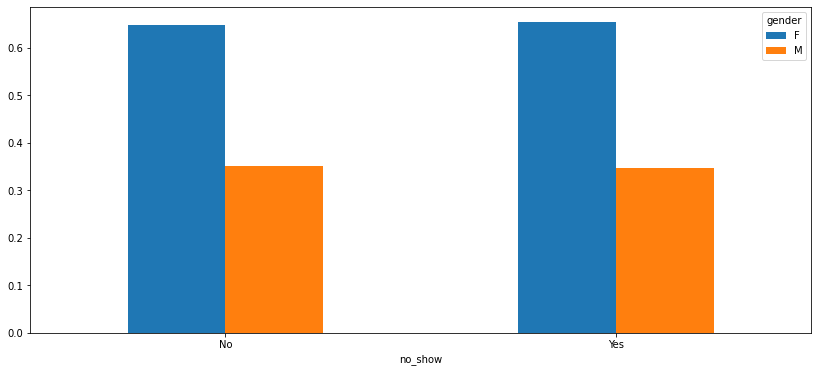

In [101]:
# gen_sho3= df.groupby('no_show')['gender'].value_counts(normalize=True).unstack()
# gen_sho3.plot (kind='bar',figsize=(14,6), rot=0);

Findings:
- though females tend to preserve more appointments, gender seems to have a little or no effect upon showing of the patient at the clinic

### Question 3
#### what is the age distribution upon showing ?

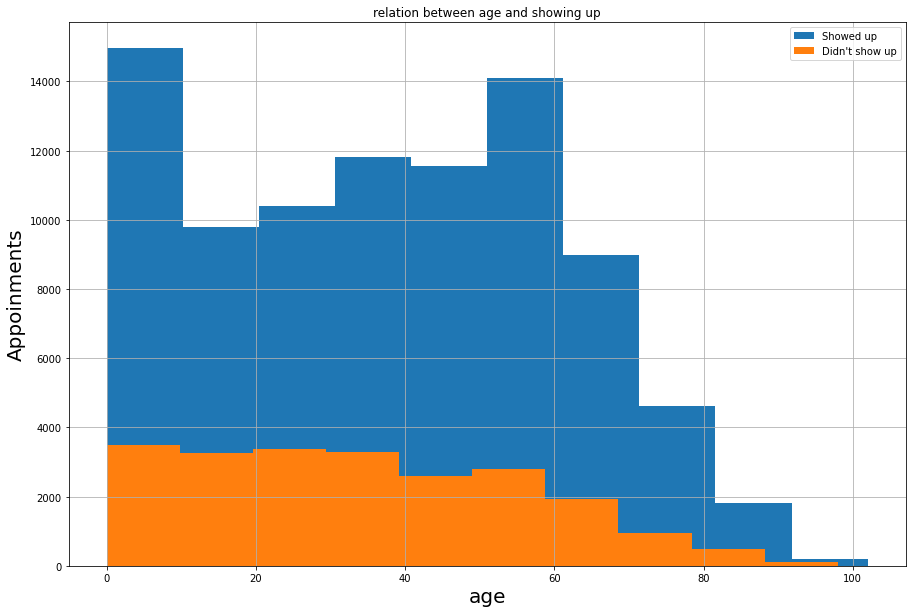

In [33]:
#ploting the count of patients show up based on thier age
df['age'][patient_show].hist(alpha=1, label='Showed up', figsize=(8, 6))
df['age'][patient_not_show].hist(alpha=1, label="Didn't show up", figsize=(15, 10))
plt.title('relation between age and showing up')
plt.xlabel('age', fontsize= 20)
plt.ylabel('Appoinments', fontsize= 20)
figsize=(8, 6)
plt.legend();

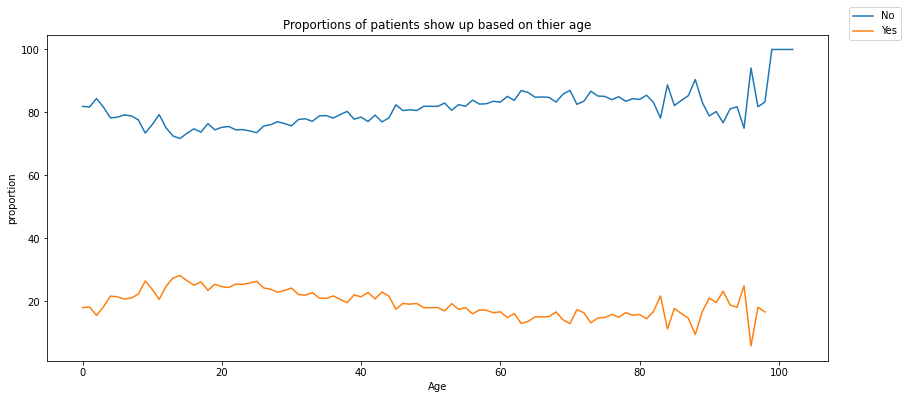

In [164]:
## ploting the Proportions of patients show up based on thier age

df.groupby('age')['no_show'].value_counts(normalize=True).unstack('no_show').mul(100).plot(figsize=[14, 6]);
plt.title('Proportions of patients show up based on thier age')
plt.xlabel('Age')
plt.ylabel('proportion')
ax = plt.gca()
plt.legend(bbox_to_anchor=(1.1, 1.1), bbox_transform=ax.transAxes);

In [57]:
#checking the average age of patients regarding show/no show
df.groupby(patient_show)['age'].mean()

no_show
False    34.306820
True     37.788753
Name: age, dtype: float64

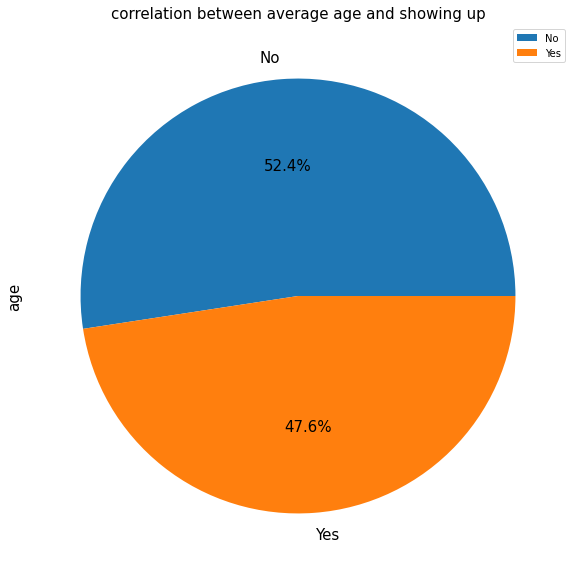

In [129]:
#plotting the correlation between average age and showing/ no showing
df.groupby('no_show')['age'].mean().plot(kind = 'pie', figsize= (10,10), fontsize = 15, autopct='%1.1f%%')
plt.legend();
plt.title('correlation between average age and showing up', fontsize=15)
plt.ylabel('age', fontsize= 15);

Findings:
- patient at young age and who are 60s tend to show up more than others
- the average age of patient who tend to show up is '34.30', while patient of average age of '37.78' tend less to show up

### Question 4
#### is there a relation between the patient being enrolled in the 'Bolsa Família' program and showing up ?

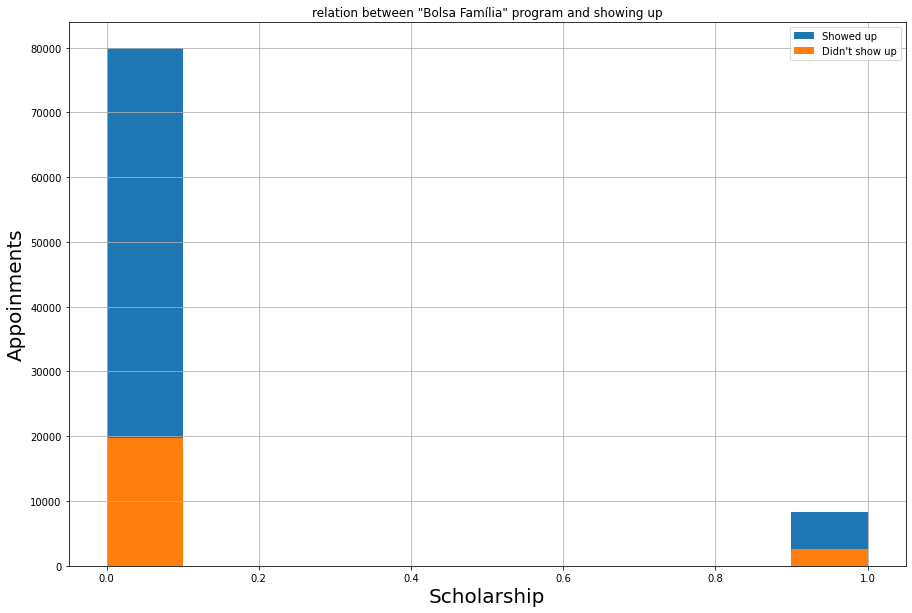

In [130]:
#plotting the correlation between Bolsa Familia participant patients and showing/ no showing
df['scholarship'][patient_show].hist(alpha=1, label='Showed up', figsize=(8, 6))
df['scholarship'][patient_not_show].hist(alpha=1, label="Didn't show up", figsize=(15, 10))
plt.title('relation between "Bolsa Família" program and showing up')
plt.xlabel('Scholarship', fontsize= 20)
plt.ylabel('Appoinments', fontsize= 20)
plt.legend();

Findings:
- patients enrolled within the 'Bolsa Família' program showed less tendency to show up

### Question 5
#### is there a relation between the patient being hypertensive and showing up ?

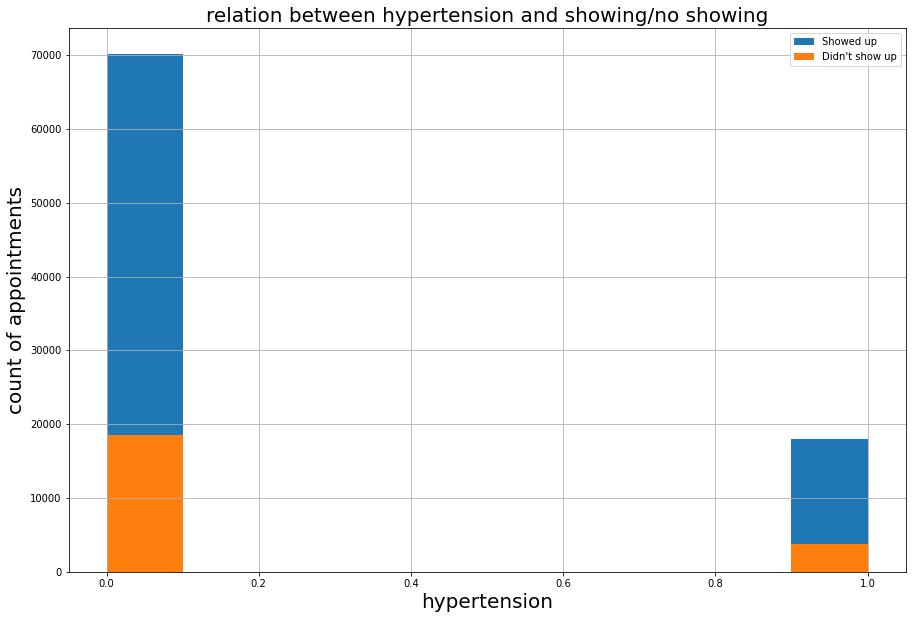

In [150]:
#creating a function to avoid repeating the block over and over and visualizing the effect of hypertension on showing/ no showing
def hist_func (column_name):
    #the function group the desired column to the (show or no show), creating a histo
    #gram revealing the number of appointment the patient attended/missed
    df[column_name][patient_show].hist(alpha=1, label='Showed up', figsize=(8, 6))
    df[column_name][patient_not_show].hist(alpha=1, label="Didn't show up", figsize=(15, 10))
    plt.title(f'relation between {column_name} and showing/no showing', fontsize = 20)
    plt.xlabel(column_name, fontsize= 20)
    plt.ylabel('count of appointments', fontsize= 20)
    plt.legend();
hist_func('hypertension')

findings:
- patients with hypertension tend less to visit the clinic compared to non-hypertensive patients

### Question 6
#### is there a relation between the patient being diabeticand showing up ?

Text(0.5, 0, 'diabetic')

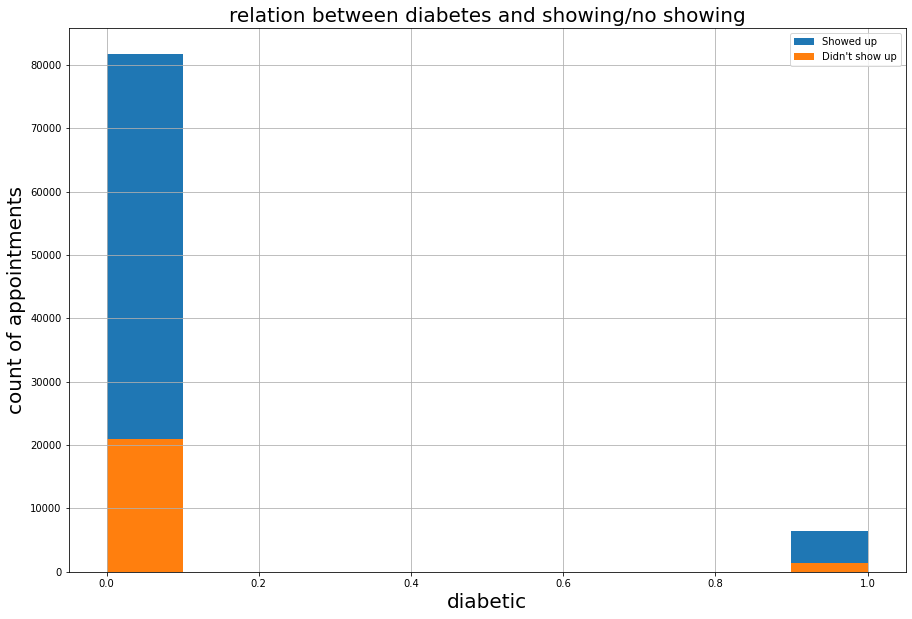

In [148]:
#plotting the correlation betwwen diabetic and non diabetic patients on showing / no showing based on number of visits
hist_func('diabetes')
plt.xlabel('diabetic')

findings:
- patients with diabetis tend less to visit the clinic compared to non-diabetic patients

### Question 7
#### is there a relation between the patient alcoholic and showing up ?

Text(0.5, 0, 'Alcoholic')

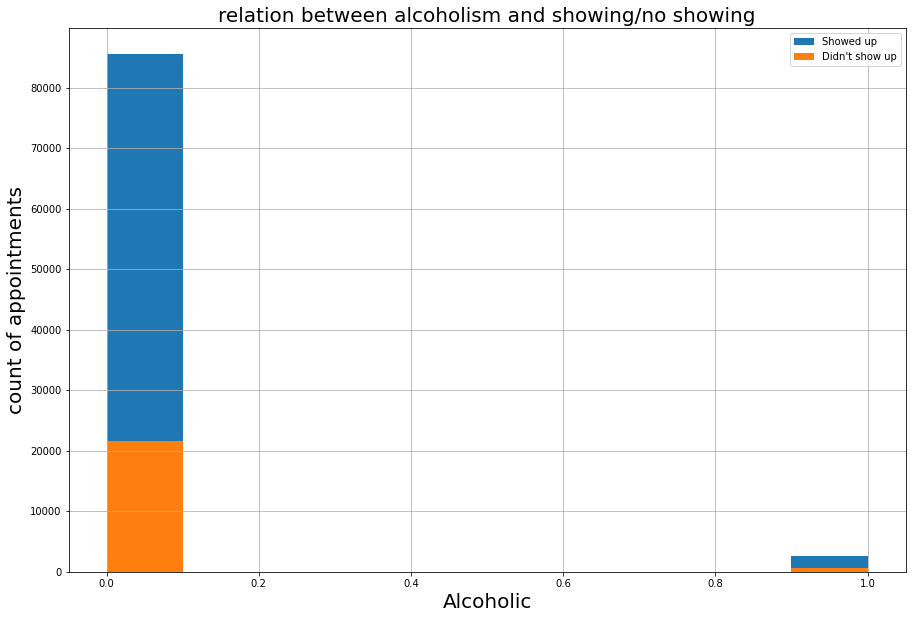

In [149]:
#plotting the correlation betwwen alcohoic and non alcoholic patients on showing / no showing based on number of visits

hist_func('alcoholism')
plt.xlabel('Alcoholic')

findings:
- patients on alcohol tend less to visit the clinic compared to non-alcoholic patients

### Question 8
#### is there a relation between the patient being handicaped and showing up ?

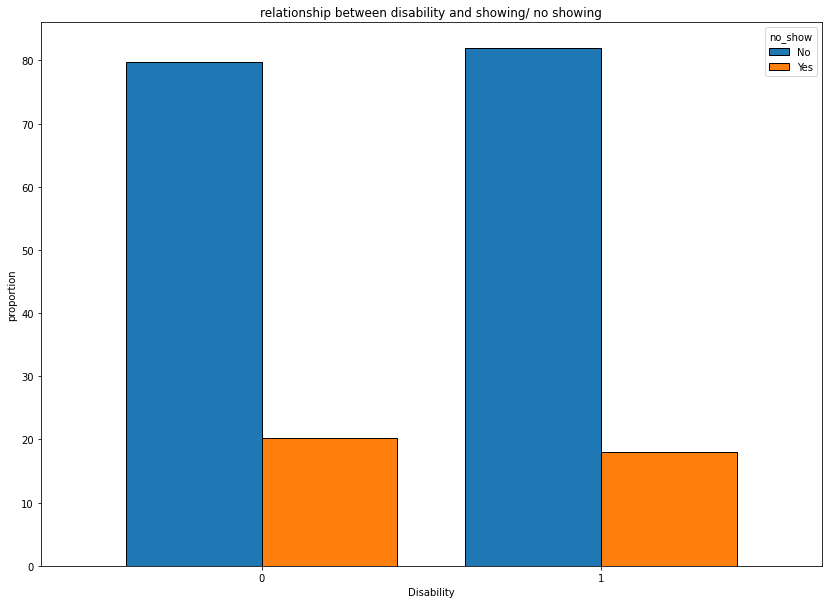

In [160]:
#plotting the correlation betwwen alcohoic and non alcoholic patients on showing / no showing based on number of visits
# not using the function to get better and easy-read visualization
df.groupby('handicaped')['no_show'].value_counts(normalize=True).unstack('no_show').mul(100).plot.bar(edgecolor= 'black', figsize=[14, 10], rot=0,width=0.8);
plt.title('relationship between disability and showing/ no showing')
plt.xlabel('Disability')
plt.ylabel('proportion');

findings:
- Handicaped patients tend less - in a very minor difference of manner -  to visit the clinic compared to non-handicaped patients

### Question 9
#### is there a relation between the patient receiving one or more SMS and showing up ?

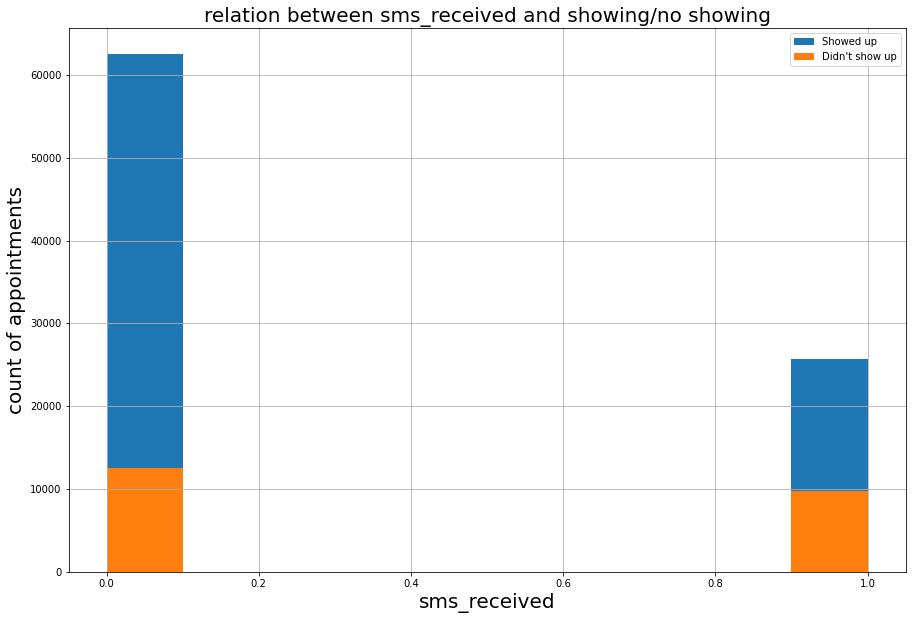

In [155]:
#plotting the correlation betwwen patients who received/not receivded SMS and showing / no showing based on number of visits

hist_func('sms_received')

Findings:
- patients who didn't receive one or more message tend to show up at the clinic more than patients who recieve

### Question 10
#### is there a relation between geographical distribution and showing up ?

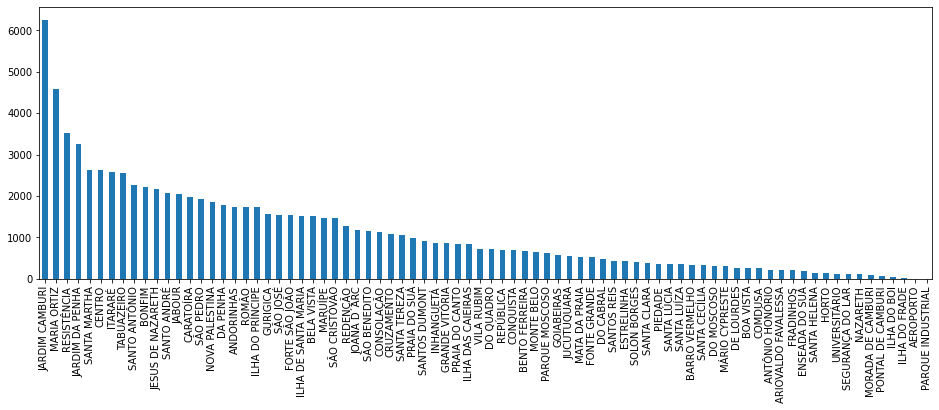

In [157]:
#plotting the relation between neighbourhoods and count of visits patients attended
df['neighbourhood'][patient_show].value_counts(normalize=False).plot(kind = 'bar', figsize=(16,5));


In [27]:
#confirming the results of the plot
df.neighbourhood.mode()[0]

'JARDIM CAMBURI'

Findings: 
- 'JARDIM CAMBURI' is the neighbourhood where his patients show up the most


<a id='conclusions'></a>
## Conclusions
- patients who didn't receive one or more message tend to show up at the clinic more than patients who recieve, SMS should be stopped for a while and make new analysis to see the impact
- 'JARDIM CAMBURI' is the neighbourhood where his patients show up the most, what is special about it, may be it has a better route
- the average age of patient who tend to show up is '34.30', while patient of average age of '37.78' tend less to show up
- age from 0 to 10 are the most showing, mostly kids and thier parents take good care of them






## Limitations
- the data will give better insights if it contains the Department visits/ scheduled to visit
- if the visit is the first time to the clinic or not
- is the visit for emergency or not
- the patient rating of the previous visit